In [1]:
import matplotlib.pyplot as plt

In [ ]:
threads = [1, 2, 4, 8, 16, 32, 64, 128]
sizes = [100, 250, 500, 1000, 1500, 2000, 2500]
times = {
    1: [0.004537, 0.083509, 0.726895, 6.333784, 30.59708, 88.744415, 188.388756],
    2: [0.002643, 0.039444, 0.388452, 3.298221, 15.891445, 47.662575, 96.38806],
    4: [0.001812, 0.031781, 0.266392, 2.480688, 12.433257, 31.99647, 60.709956],
    8: [0.001221, 0.016049, 0.132841, 1.141829, 5.649443, 15.175328, 26.012024],
    16: [0.001364, 0.012287, 0.106558, 0.785987, 3.436021, 8.533451, 18.741478],
    32: [0.001848, 0.013162, 0.093196, 0.839308, 3.227548, 8.167639, 17.26227],
    64: [0.003637, 0.012315, 0.080633, 0.778089, 3.088063, 8.102538, 17.957636],
    128: [0.006114, 0.015618, 0.085946, 0.783255, 2.999966, 7.683768, 16.869313]
}

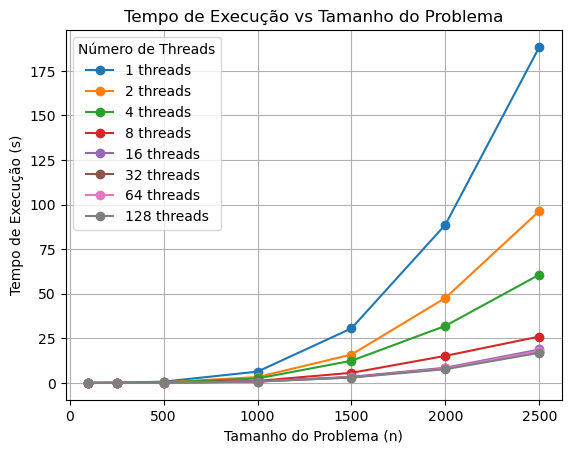

In [3]:
for t in threads:
    plt.plot(sizes, times[t], marker='o', label=f'{t} threads')

plt.xlabel("Tamanho do Problema (n)")
plt.ylabel("Tempo de Execução (s)")
plt.title("Tempo de Execução vs Tamanho do Problema")
plt.legend(title="Número de Threads")
plt.grid()
plt.show()

In [5]:
import seaborn as sns
import numpy as np
import pandas as pd

In [ ]:
def plot_bar_chart():
    x = np.arange(len(sizes)) 
    width = 0.1  
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for idx, t in enumerate(threads):
        if t in times:
            ax.bar(x + idx * width, times[t], width, label=f'{t} threads')
    
    ax.set_xlabel("Tamanho do Problema (n)")
    ax.set_ylabel("Tempo de Execução (s)")
    ax.set_title("Tempo de Execução por Número de Threads")
    ax.set_xticks(x + width * len(threads) / 2)
    ax.set_xticklabels(sizes)
    ax.legend(title="Número de Threads")
    plt.grid()
    plt.show()


In [ ]:
def plot_speedup():
    speedups = {}
    for t in threads:
        if t in times:
            speedups[t] = [times[1][i] / times[t][i] for i in range(len(sizes))]

    for t in threads:
        if t in speedups:
            plt.plot(sizes, speedups[t], marker='o', label=f'{t} threads')

    plt.xlabel("Tamanho do Problema (n)")
    plt.ylabel("Speedup")
    plt.title("Speedup em Relação ao Tempo Sequencial (1 Thread)")
    plt.legend(title="Número de Threads")
    plt.grid()
    plt.show()

In [ ]:
def plot_efficiency():
    efficiencies = {}
    for t in threads:
        if t in times:
            efficiencies[t] = [(times[1][i] / times[t][i]) / t for i in range(len(sizes))]

    for t in threads:
        if t in efficiencies:
            plt.plot(sizes, efficiencies[t], marker='o', label=f'{t} threads')

    plt.xlabel("Tamanho do Problema (n)")
    plt.ylabel("Eficiência")
    plt.title("Eficiência do Paralelismo")
    plt.legend(title="Número de Threads")
    plt.grid()
    plt.show()

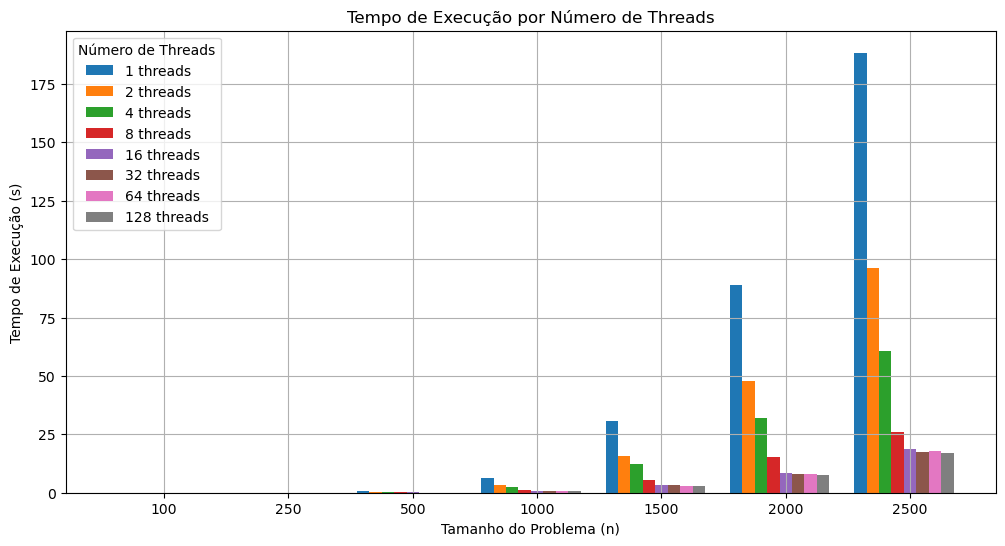

In [9]:
plot_bar_chart()

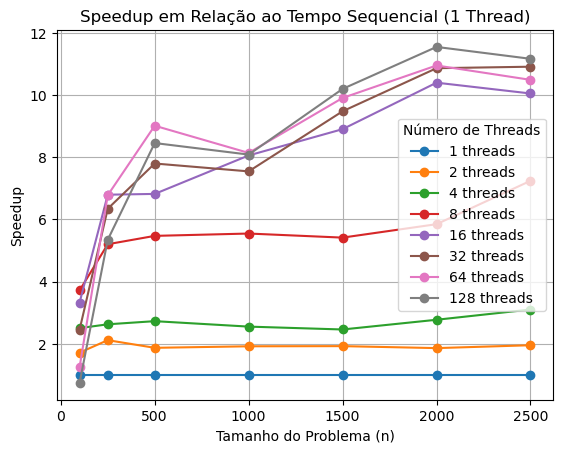

In [10]:
plot_speedup()

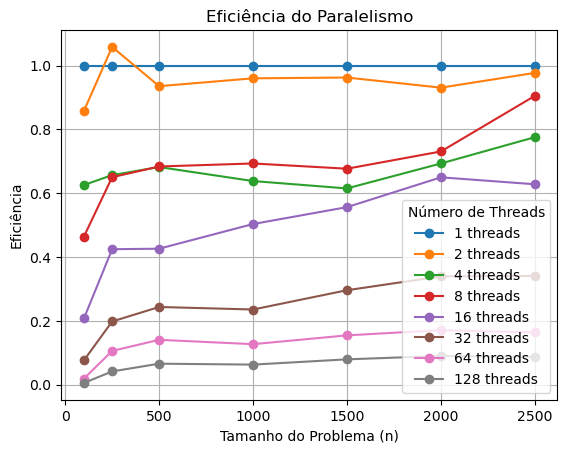

In [11]:
plot_efficiency()

In [ ]:
heatmap_data = pd.DataFrame(
    data=[times[t] for t in threads],
    index=[t for t in threads],
    columns=[f"{size}" for size in sizes]
)


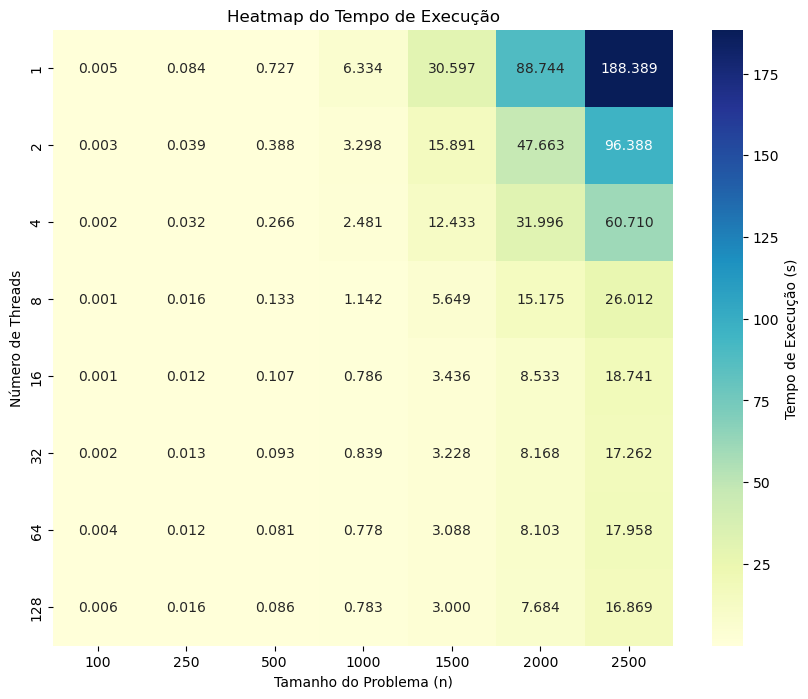

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={'label': 'Tempo de Execução (s)'})
plt.title("Heatmap do Tempo de Execução")
plt.xlabel("Tamanho do Problema (n)")
plt.ylabel("Número de Threads")
plt.show()